# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [2]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [3]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [4]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [5]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


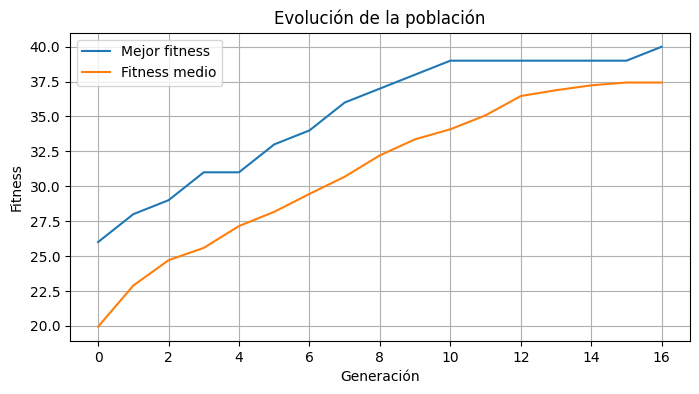

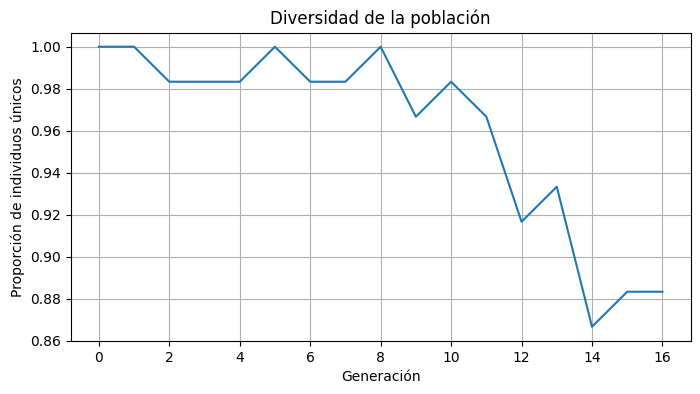

In [6]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [7]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [ ]:
def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population]
    total_fitness = sum(fitnesses)

    # Si toda la población tiene fitness 0, la ruleta no tiene "peso" que repartir:
    # se elige uniformemente al azar para evitar dividir por cero.
    if total_fitness == 0:
        return rng.choice(population).copy()

    pick = rng.uniform(0, total_fitness)
    cumulative = 0
    for individual, f in zip(population, fitnesses):
        cumulative += f
        if cumulative >= pick:
            return individual.copy()

    # Fallback por seguridad numérica (redondeo de floats)
    return population[-1].copy()

# Prueba 
test_population = [create_individual(12, rng) for _ in range(8)]
picked = roulette_selection(test_population, rng)
print('Seleccionado:', as_string(picked), 'fitness =', fitness(picked))


Seleccionado: 000010010011 fitness = 4


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [ ]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1, child2 = [], []
    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    return child1, child2

# Prueba
p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = uniform_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))


Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11000101
Hijo 2 : 00111010


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

Mejor frase encontrada: INTELIGENCIA ARTIFICIAL
Fitness: 23 / 23
Generaciones ejecutadas: 44


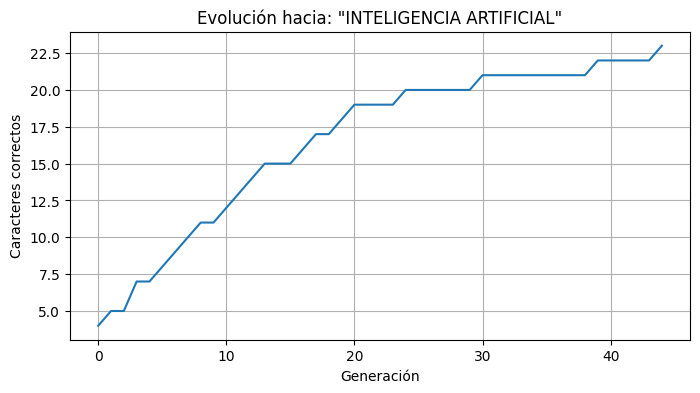

In [10]:
# Actividad 3 — evolucionar una frase objetivo
import string

TARGET_PHRASE = "INTELIGENCIA ARTIFICIAL"
ALPHABET = string.ascii_uppercase + " "


def create_phrase_individual(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]


def phrase_fitness(individual, target=TARGET_PHRASE):
    return sum(1 for gene, target_gene in zip(individual, target) if gene == target_gene)


def phrase_as_string(individual):
    return ''.join(individual)


def phrase_tournament_selection(population, tournament_size, rng, target):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=lambda ind: phrase_fitness(ind, target)).copy()


def phrase_mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)
    return child


def genetic_algorithm_phrase(
    target=TARGET_PHRASE,
    population_size=200,
    generations=500,
    crossover_rate=0.9,
    mutation_rate=0.02,
    tournament_size=3,
    elitism=True,
    seed=0
):
    rng = random.Random(seed)
    length = len(target)
    population = [create_phrase_individual(length, rng) for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [phrase_fitness(ind, target) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'best_string': phrase_as_string(best)
        })

        if max(fitnesses) == length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = phrase_tournament_selection(population, tournament_size, rng, target)
            parent2 = phrase_tournament_selection(population, tournament_size, rng, target)
            # Reutilizamos el cruce de un punto ya implementado (funciona con cualquier
            # tipo de gen, no solo bits).
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = phrase_mutate(child1, mutation_rate, rng)
            child2 = phrase_mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_string'], history


best_phrase, phrase_history = genetic_algorithm_phrase(seed=SEED)
print('Mejor frase encontrada:', best_phrase)
print('Fitness:', phrase_history[-1]['best'], '/', len(TARGET_PHRASE))
print('Generaciones ejecutadas:', phrase_history[-1]['generation'])

plt.figure(figsize=(8, 4))
plt.plot([h['generation'] for h in phrase_history], [h['best'] for h in phrase_history])
plt.xlabel('Generación')
plt.ylabel('Caracteres correctos')
plt.title(f'Evolución hacia: "{TARGET_PHRASE}"')
plt.grid(True)
plt.show()


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

Con elitismo — ¿bajó el mejor fitness en algún punto?: False
Sin elitismo — ¿bajó el mejor fitness en algún punto?: True


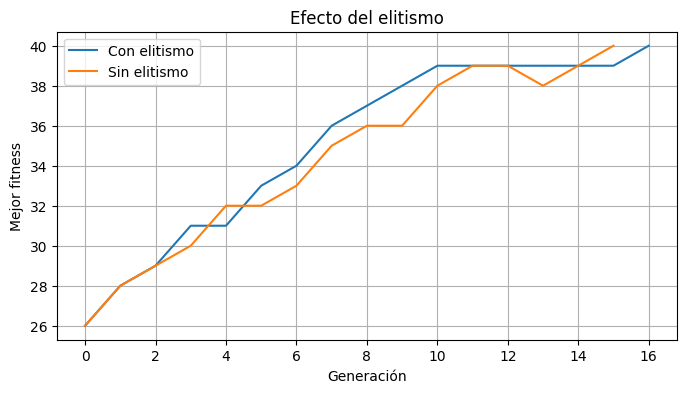

In [11]:
# Actividad 4 — efecto del elitismo
best_elite, history_elite = genetic_algorithm(elitism=True, seed=SEED)
best_no_elite, history_no_elite = genetic_algorithm(elitism=False, seed=SEED)


def best_ever_decreased(history):
    bests = [h['best'] for h in history]
    return any(b2 < b1 for b1, b2 in zip(bests, bests[1:]))


print('Con elitismo — ¿bajó el mejor fitness en algún punto?:', best_ever_decreased(history_elite))
print('Sin elitismo — ¿bajó el mejor fitness en algún punto?:', best_ever_decreased(history_no_elite))

plt.figure(figsize=(8, 4))
plt.plot([h['generation'] for h in history_elite], [h['best'] for h in history_elite], label='Con elitismo')
plt.plot([h['generation'] for h in history_no_elite], [h['best'] for h in history_no_elite], label='Sin elitismo')
plt.xlabel('Generación')
plt.ylabel('Mejor fitness')
plt.title('Efecto del elitismo')
plt.legend()
plt.grid(True)
plt.show()


**Respuesta — Actividad 4:**

Sí, **sin elitismo el mejor fitness puede disminuir** de una generación a la siguiente. La razón es que, sin elitismo, *ningún* individuo pasa garantizado a la siguiente generación: incluso el mejor individuo actual debe "competir" de nuevo a través de selección, cruce y mutación, todos procesos estocásticos. Puede no ser elegido como padre, o ser elegido pero destruido por el cruce (al combinarse con un padre peor) o por la mutación. Como toda la nueva población se construye desde cero a partir de esos procesos aleatorios, no hay ninguna garantía de que el mejor individuo (o algo igual de bueno) sobreviva intacto.

Con elitismo, en cambio, el mejor individuo se copia directamente a la siguiente generación, por lo que el mejor fitness de la población es **monótono no decreciente** generación tras generación, nunca puede empeorar.

## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing?
2. ¿Por qué el cruce no garantiza hijos mejores que sus padres?
3. ¿Qué significa convergencia prematura?
4. ¿Qué parámetros controlan la exploración?

### Respuestas - preguntas de cierre

1. **¿Qué papel cumple la población que no existe en Hill Climbing?** La población mantiene muchas soluciones candidatas explorando el espacio de búsqueda en paralelo, en vez de seguir un único estado. Esto le da al algoritmo genético dos cosas que Hill Climbing no tiene: diversidad (varias regiones del espacio exploradas a la vez) y la posibilidad de recombinar información útil de distintos individuos mediante el cruce, en vez de depender solo de perturbaciones locales de una única solución.

2. **¿Por qué el cruce no garantiza hijos mejores que sus padres?** El cruce combina fragmentos de dos padres a ciegas, sin evaluar si esa combinación específica tiene sentido: puede juntar la "mitad buena" de un padre con la "mitad mala" del otro y producir un hijo peor que ambos padres. La mejora no viene de garantizar que cada cruce sea bueno, sino de que, en conjunto y a lo largo de muchas generaciones, la selección favorece a los individuos (e indirectamente a las combinaciones de genes) que sí funcionan bien.

3. **¿Qué significa convergencia prematura?** Es cuando la población pierde diversidad muy rápido, casi todos se parecen entre sí, y el algoritmo queda estancado en un óptimo local sin haber explorado el resto del espacio del espacio de búsqueda. En ese punto el cruce ya no aporta nada nuevo porque todos son casi iguales, y solo la mutación puede meter algo de variedad, aunque suele ser lenta.

4. **¿Qué parámetros controlan la exploración?** Principalmente: la tasa de mutación (más alta = más exploración/ruido), el tamaño del torneo de selección (más pequeño = menor presión de selección = más exploración, individuos débiles tienen más chance), el tamaño de la población (más grande = más diversidad simultánea) y si se usa elitismo (sin elitismo hay más variabilidad entre generaciones, a costa de poder perder buenas soluciones).